# LangGraph live optimization comparison across Trace / OTEL / sys.monitoring

This notebook runs the live comparison module and renders a shared analysis report.

- It uses the OpenRouter API when `OPENROUTER_API_KEY` is set.
- It defaults to `OPENROUTER_MODEL=google/gemini-3-flash-preview` when the model env var is absent.
- In CI or local runs without credentials, it prints a skip message and exits successfully.


## Optimization comparison

_Topology metrics remain useful even when score trajectories match, for example under the fixed offline prompt schedule._

| config | runtime_s | baseline | best | gain | best_iteration | stability_std | node_count | edge_count | score_history |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---|
| trace | 22.643 | 0.733 | 0.803 | 0.070 | 2 | 0.000 | 9 | 6 | [0.733, 0.733, 0.803] |
| trace+otel | 20.681 | 0.733 | 0.733 | 0.000 | 0 | 0.000 | 9 | 6 | [0.733, 0.733, 0.677] |
| otel | 21.909 | 0.733 | 0.837 | 0.103 | 2 | 0.000 | 6 | 5 | [0.733, 0.733, 0.837] |
| trace+sysmon | 18.639 | 0.733 | 0.733 | 0.000 | 0 | 0.000 | 9 | 6 | [0.733, 0.733, 0.65] |
| trace+otel+sysmon | 22.479 | 0.733 | 0.733 | 0.000 | 0 | 0.000 | 9 | 6 | [0.733, 0.733, 0.677] |
| otel+sysmon | 21.463 | 0.733 | 0.915 | 0.182 | 2 | 0.000 | 6 | 5 | [0.733, 0.733, 0.915] |
| sysmon | 20.267 | 0.733 | 0.854 | 0.121 | 2 | 0.000 | 4 | 3 | [0.733, 0.733, 0.854] |

## trace
- Runtime: `22.643s`
- Baseline score: `0.733`
- Best score: `0.803`
- Score gain: `0.070`
- Best iteration: `2`
- Post-update stability std: `0.000`
- Node count: `9`
- Edge count: `6`
- Score history: `[0.733, 0.733, 0.803]`
- Best updates: `['synth_prompt']`

### Final synth prompt
```text
Provide a direct, factual summary for the following query. Organize the information into clear sections or paragraphs following the logical flow of the provided plan. Ensure each main point from the plan is represented as a distinct part of the summary.

Query: {query}
Source Plan: {plan}
```
### Final answer
```text
CRISPR is a revolutionary gene-editing technology that allows scientists to make precise changes to the DNA of living organisms. The following summary details its function, origins, and the mechanisms that make it a transformative tool in modern science.

### **1. The Definition (The "What")**
CRISPR stands for **Clustered Regularly Interspaced Short Palindromic Repeats**. In practical terms, it is often described as "molecular scissors" or a "search-and-replace" function for the genome. The ...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['final_answer_node', 'getitem', 'make_trace_case.planner_node', 'make_trace_case.planner_node3_copy', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Provide a direct, factual summary for the following query. Organize the information into clear sections or paragraphs following the logical flow of the provided plan. Ensure each main point from the plan is represente..."
}
```

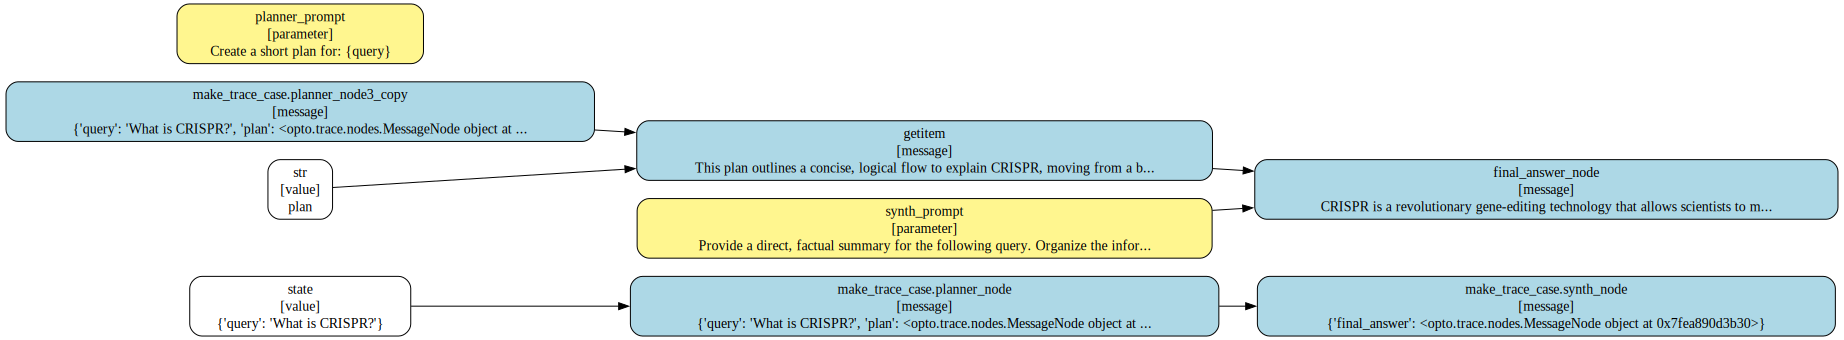

## trace+otel
- Runtime: `20.681s`
- Baseline score: `0.733`
- Best score: `0.733`
- Score gain: `0.000`
- Best iteration: `0`
- Post-update stability std: `0.000`
- Node count: `9`
- Edge count: `6`
- Score history: `[0.733, 0.733, 0.677]`
- Best updates: `[]`

### Final synth prompt
```text
Provide a direct, factual explanation of the topic based on the provided plan. Start your response immediately with the definition. Do not use conversational filler, introductory remarks, or concluding summaries. Present the information concisely.

Query: {query}
Plan: {plan}
```
### Final answer
```text
**CRISPR** (Clustered Regularly Interspaced Short Palindromic Repeats) is a revolutionary gene-editing technology that functions as "molecular scissors" or a "search-and-replace" tool for DNA. It consists of two primary components: **Cas9**, an enzyme that cuts the DNA strands, and **Guide RNA (gRNA)**, a programmed sequence that directs the Cas9 enzyme to a specific location in the genome.

The system was adapted from a naturally occurring immune mechanism in bacteria, which use CRISPR seque...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['final_answer_node', 'getitem', 'make_trace_case.planner_node', 'make_trace_case.planner_node7_copy', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Provide a direct, factual explanation of the topic based on the provided plan. Start your response immediately with the definition. Do not use conversational filler, introductory remarks, or concluding summaries. Pres..."
}
```

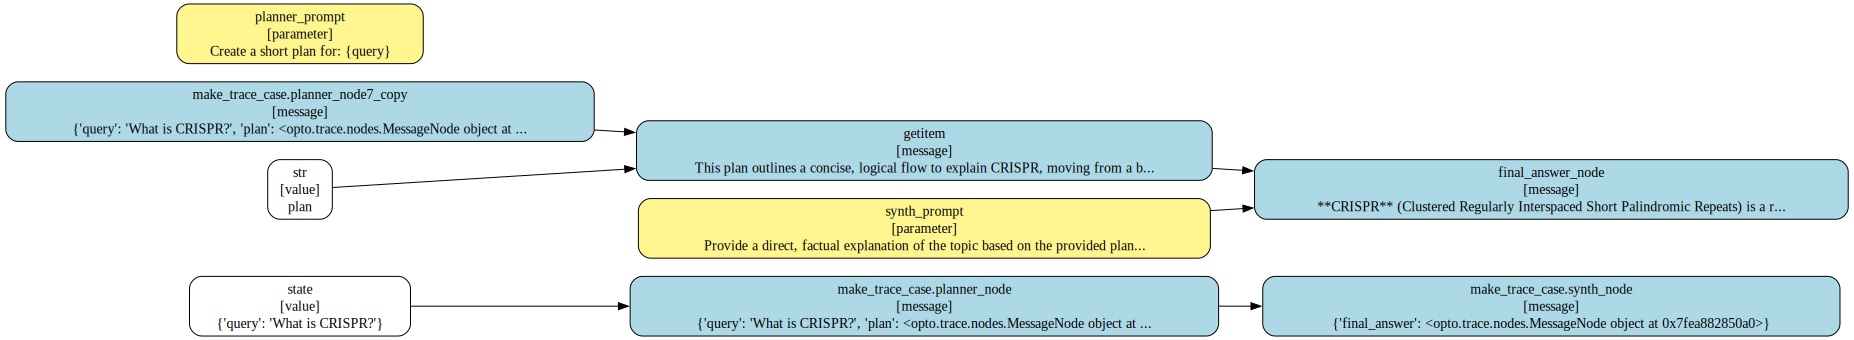

### observer otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `2`
- Span names: `['planner_node', 'synth_node']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Provide a direct, factual explanation of the topic based on the provided plan. Start your response immediately with the definition. Do not use conversational filler, introductory remarks, or concluding summaries. Pres..."
}
```

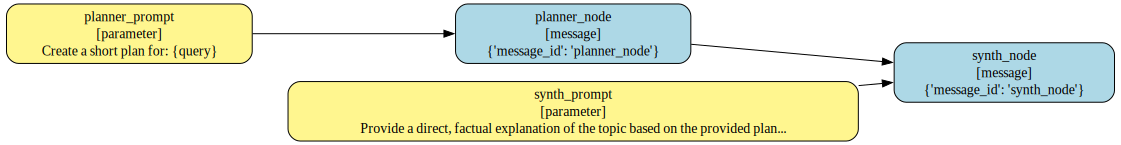

## otel
- Runtime: `21.909s`
- Baseline score: `0.733`
- Best score: `0.837`
- Score gain: `0.103`
- Best iteration: `2`
- Post-update stability std: `0.000`
- Node count: `6`
- Edge count: `5`
- Score history: `[0.733, 0.733, 0.837]`
- Best updates: `['planner_prompt', 'synth_prompt']`

### Final synth prompt
```text
You are a science communicator. Using the structured plan provided below, write a thorough, engaging, and clear response to the user's query: {query}. 

Follow the plan strictly, using its sections as headers for your response. Explain all technical concepts (like enzymes or DNA sequences) in a way that remains accessible to a non-expert audience while maintaining scientific accuracy.

Plan:
{plan}
```
### Final answer
```text
### **I. Definition and Historical Context**

#### **A. Technical Definition**
CRISPR stands for **Clustered Regularly Interspaced Short Palindromic Repeats**. To visualize this, imagine a long sentence where the same word is repeated over and over, but between those repeats are unique "spacer" sequences. In biological terms, these are specific patterns of DNA nucleotides (the building blocks of life) found in the genomes of microorganisms.

#### **B. The Biological Origin**
While we now thin...
```

### backend otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['llm.chat.completion', 'llm.chat.completion', 'planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `5`
- Span names: `['llm.chat.completion', 'planner_node', 'llm.chat.completion', 'synth_node', 'langgraph-agent.invoke']`

```json
{
  "planner_prompt": "As an expert scientific strategist, create a comprehensive and structured outline to explain the following topic: {query}. The outline must include: 1) A clear definition and historical context, 2) The step-by-step bi...",
  "synth_prompt": "You are a science communicator. Using the structured plan provided below, write a thorough, engaging, and clear response to the user's query: {query}. \n\nFollow the plan strictly, using its sections as headers for your..."
}
```

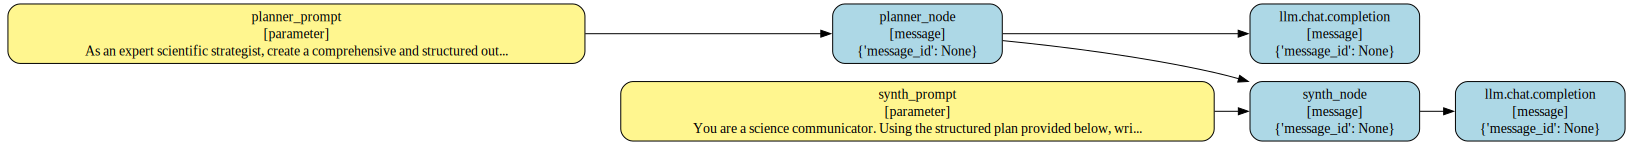

## trace+sysmon
- Runtime: `18.639s`
- Baseline score: `0.733`
- Best score: `0.733`
- Score gain: `0.000`
- Best iteration: `0`
- Post-update stability std: `0.000`
- Node count: `9`
- Edge count: `6`
- Score history: `[0.733, 0.733, 0.65]`
- Best updates: `[]`

### Final synth prompt
```text
Synthesize the following plan into a single, direct, and cohesive factual explanation. Provide the information as a continuous response without using bold headers, bullet points, or introductory filler. Focus on delivering the facts immediately.

Query: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR, which stands for Clustered Regularly Interspaced Short Palindromic Repeats, is a revolutionary gene-editing technology that functions as a pair of molecular scissors or a search-and-replace tool for DNA. The system relies on two primary components: the Cas9 enzyme, which performs the physical cutting of the genetic material, and a guide RNA molecule that acts as a GPS to direct the enzyme to a precise location within the genome. This mechanism was originally adapted from a naturally o...
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['final_answer_node', 'getitem', 'make_trace_case.planner_node', 'make_trace_case.planner_node11_copy', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Synthesize the following plan into a single, direct, and cohesive factual explanation. Provide the information as a continuous response without using bold headers, bullet points, or introductory filler. Focus on deliv..."
}
```

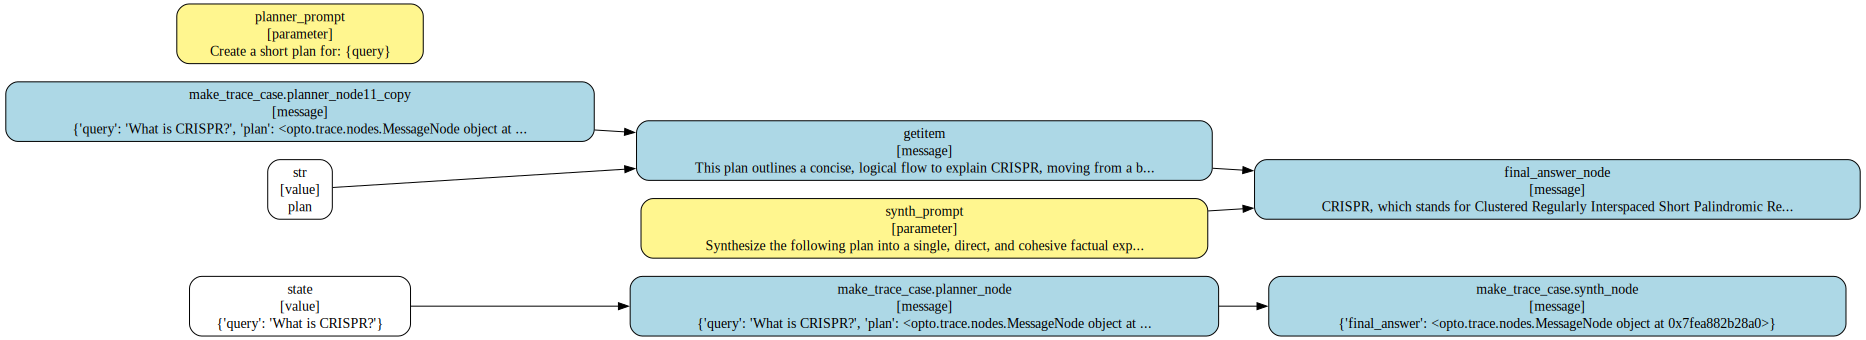

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Synthesize the following plan into a single, direct, and cohesive factual explanation. Provide the information as a continuous response without using bold headers, bullet points, or introductory filler. Focus on deliv..."
}
```

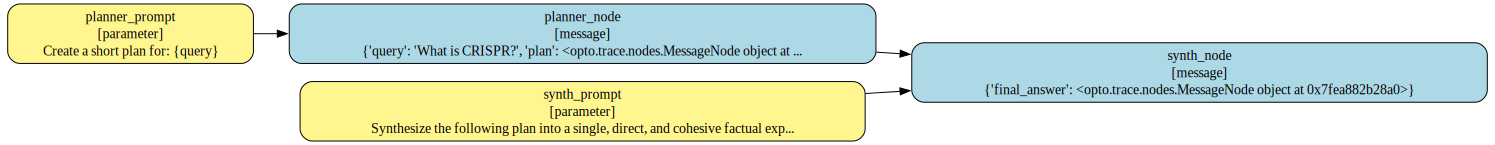

## trace+otel+sysmon
- Runtime: `22.479s`
- Baseline score: `0.733`
- Best score: `0.733`
- Score gain: `0.000`
- Best iteration: `0`
- Post-update stability std: `0.000`
- Node count: `9`
- Edge count: `6`
- Score history: `[0.733, 0.733, 0.677]`
- Best updates: `[]`

### Final synth prompt
```text
Respond to the topic using the provided plan. Your response must be extremely direct: start immediately with the facts, remove all section headings (like "###"), and do not use introductory or concluding remarks. Ensure every sentence is complete and strictly follows the logical flow of the plan.

Topic: {query}
Plan: {plan}

Direct Response:
```
### Final answer
```text
CRISPR stands for Clustered Regularly Interspaced Short Palindromic Repeats and functions as a revolutionary gene-editing tool. It is frequently described as "molecular scissors" or a "search-and-replace" function for the genome, allowing scientists to modify DNA with high precision. The system consists of two primary components: the Cas9 enzyme, which acts as the scissors to cut the DNA strand, and the Guide RNA (gRNA), which serves as a GPS to lead the enzyme to a specific genetic sequence....
```

### backend trace
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['final_answer_node', 'getitem', 'make_trace_case.planner_node', 'make_trace_case.planner_node15_copy', 'make_trace_case.synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Respond to the topic using the provided plan. Your response must be extremely direct: start immediately with the facts, remove all section headings (like \"###\"), and do not use introductory or concluding remarks. Ensu..."
}
```

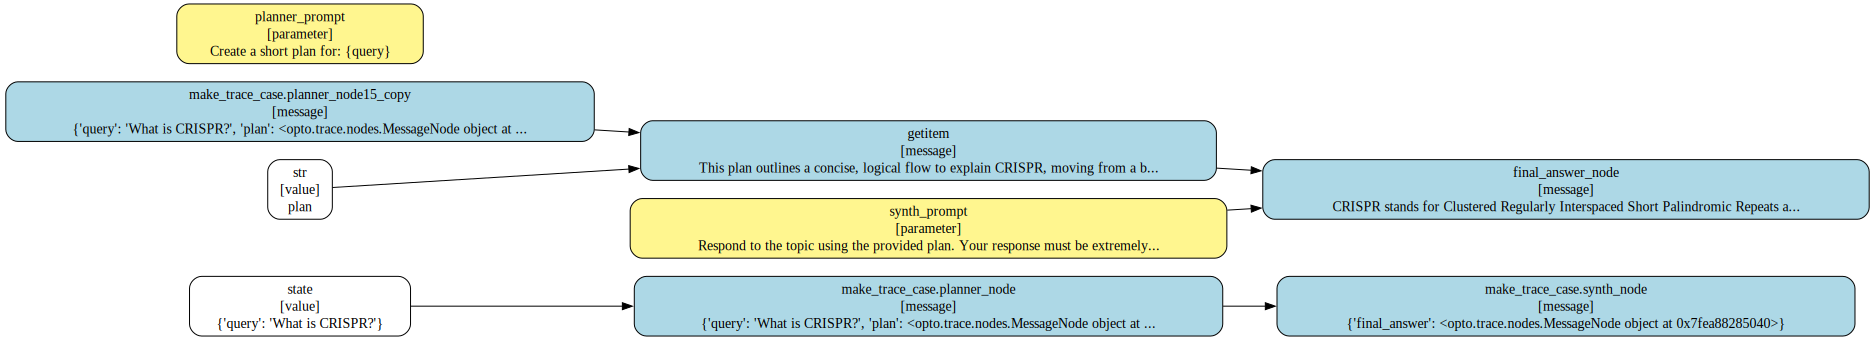

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Respond to the topic using the provided plan. Your response must be extremely direct: start immediately with the facts, remove all section headings (like \"###\"), and do not use introductory or concluding remarks. Ensu..."
}
```

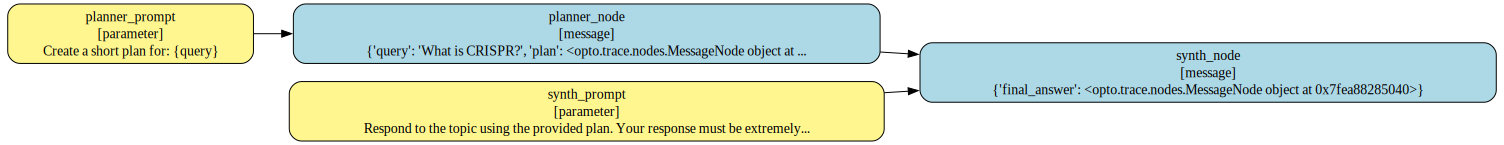

### observer otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `2`
- Span names: `['planner_node', 'synth_node']`

```json
{
  "planner_prompt": "Create a short plan for: {query}",
  "synth_prompt": "Respond to the topic using the provided plan. Your response must be extremely direct: start immediately with the facts, remove all section headings (like \"###\"), and do not use introductory or concluding remarks. Ensu..."
}
```

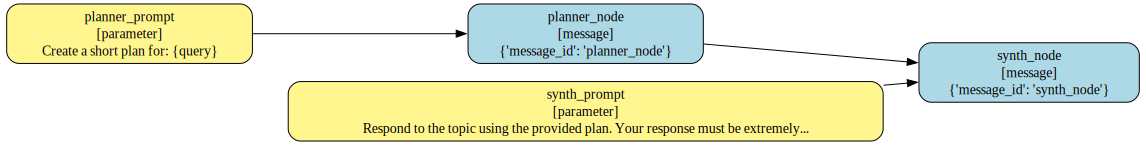

## otel+sysmon
- Runtime: `21.463s`
- Baseline score: `0.733`
- Best score: `0.915`
- Score gain: `0.182`
- Best iteration: `2`
- Post-update stability std: `0.000`
- Node count: `6`
- Edge count: `5`
- Score history: `[0.733, 0.733, 0.915]`
- Best updates: `['planner_prompt', 'synth_prompt']`

### Final synth prompt
```text
Act as an expert scientific communicator. Using the detailed plan provided below, write a factual, clear, and engaging response to the user's query: {query}. 

Instructions:
- Expand on each point of the plan with accurate details.
- Use a professional yet accessible tone.
- Ensure smooth transitions between the definition, components, and significance sections.
- Conclude with a summary of the technology's impact.

Plan:
{plan}
```
### Final answer
```text
To understand the future of medicine and biotechnology, one must understand **CRISPR**. Often described as the most significant biological discovery of the 21st century, CRISPR has transformed from an obscure bacterial defense mechanism into a powerful tool for rewriting the code of life.

### I. Definition and Etymology: The Blueprint of the System
At its most basic level, **CRISPR** stands for **Clustered Regularly Interspaced Short Palindromic Repeats**. While the name is a mouthful, it de...
```

### backend otel
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['llm.chat.completion', 'llm.chat.completion', 'planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Span count: `5`
- Span names: `['llm.chat.completion', 'planner_node', 'llm.chat.completion', 'synth_node', 'langgraph-agent.invoke']`

```json
{
  "planner_prompt": "Create a detailed and structured outline for a comprehensive answer to the query: {query}. \nThe plan must include:\n1. A clear definition and etymology.\n2. A breakdown of key biological and technical components.\n3. Spe...",
  "synth_prompt": "Act as an expert scientific communicator. Using the detailed plan provided below, write a factual, clear, and engaging response to the user's query: {query}. \n\nInstructions:\n- Expand on each point of the plan with acc..."
}
```

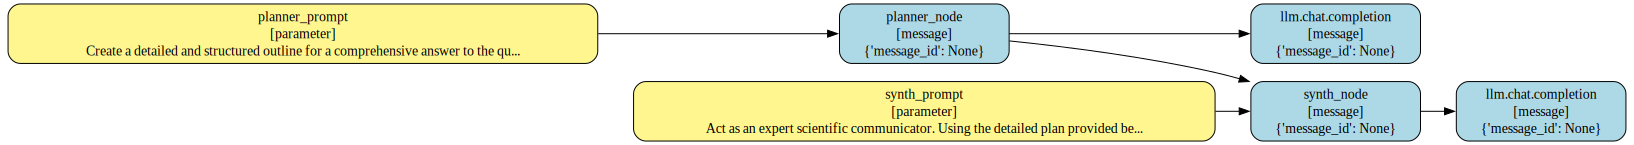

### observer sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Create a detailed and structured outline for a comprehensive answer to the query: {query}. \nThe plan must include:\n1. A clear definition and etymology.\n2. A breakdown of key biological and technical components.\n3. Spe...",
  "synth_prompt": "Act as an expert scientific communicator. Using the detailed plan provided below, write a factual, clear, and engaging response to the user's query: {query}. \n\nInstructions:\n- Expand on each point of the plan with acc..."
}
```

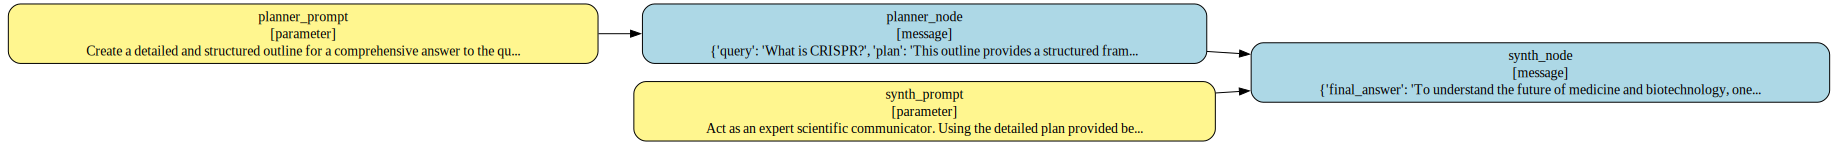

## sysmon
- Runtime: `20.267s`
- Baseline score: `0.733`
- Best score: `0.854`
- Score gain: `0.121`
- Best iteration: `2`
- Post-update stability std: `0.000`
- Node count: `4`
- Edge count: `3`
- Score history: `[0.733, 0.733, 0.854]`
- Best updates: `['planner_prompt', 'synth_prompt']`

### Final synth prompt
```text
Give a direct, factual answer to the query using the provided plan. Do not include any introductory remarks, conversational filler, or meta-commentary. Start your response immediately with the answer.

Query: {query}
Plan: {plan}
```
### Final answer
```text
CRISPR (Clustered Regularly Interspaced Short Palindromic Repeats) is a gene-editing technology that allows scientists to precisely modify DNA within living organisms. It is adapted from a naturally occurring immune system in bacteria used to destroy the DNA of invading viruses.

The system, commonly known as CRISPR-Cas9, consists of two main components:
*   **Cas9:** An enzyme that acts as "molecular scissors" to cut the DNA.
*   **Guide RNA (gRNA):** A pre-designed RNA sequence that leads t...
```

### backend sysmon
- Semantic message names: `['planner_node', 'synth_node']`
- All message names: `['planner_node', 'synth_node']`
- Parameter names: `['planner_prompt', 'synth_prompt']`
- Event count: `2`

```json
{
  "planner_prompt": "Provide a concise list of key factual points to answer: {query}",
  "synth_prompt": "Give a direct, factual answer to the query using the provided plan. Do not include any introductory remarks, conversational filler, or meta-commentary. Start your response immediately with the answer.\n\nQuery: {query}\n..."
}
```

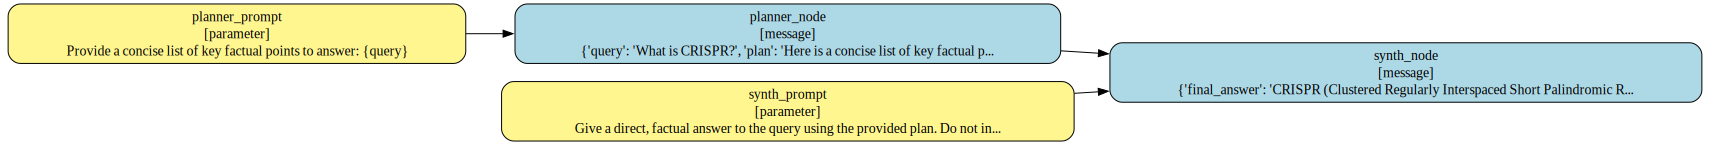

[{'config': 'trace',
  'runtime_s': 22.643,
  'baseline_score': 0.733,
  'best_score': 0.803,
  'score_gain': 0.07,
  'best_iteration': 2,
  'score_history': [0.733, 0.733, 0.803],
  'stability_std': 0.0,
  'node_count': 9,
  'edge_count': 6,
  'best_updates': {'synth_prompt': 'Provide a direct, factual summary for the following query. Do not include introductory text, headers, or structural labels. Use the provided plan for factual content only: {query}\nSource Content: {plan}'},
  'final_synth_prompt': 'Provide a direct, factual summary for the following query. Organize the information into clear sections or paragraphs following the logical flow of the provided plan. Ensure each main point from the plan is represented as a distinct part of the summary.\n\nQuery: {query}\nSource Plan: {plan}',
  'final_answer': 'CRISPR is a revolutionary gene-editing technology that allows scientists to make precise changes to the DNA of living organisms. The following summary details its function, or

In [1]:
import importlib.util
from pathlib import Path

candidates = [
    Path('examples/notebooks/demo_langgraph_instrument_and_compare_observers.py'),
    Path('demo_langgraph_instrument_and_compare_observers.py'),
]

for candidate in candidates:
    if candidate.exists():
        spec = importlib.util.spec_from_file_location('compare_observers_demo', candidate)
        module = importlib.util.module_from_spec(spec)
        assert spec.loader is not None
        spec.loader.exec_module(module)
        rows = module.run_notebook_demo()
        break
else:
    raise FileNotFoundError('Could not locate demo_langgraph_instrument_and_compare_observers.py')

rows
